# MHN Predictions

This notebook reproduces the figures of section 2.

In [ ]:
from analysis.utils import analysis as mcmc_analysis
import mhn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotting
import matplotlib as mpl

import sys
sys.path.append("../MCMC-sampling-for-MHN")


model = mhn.model.oMHN.load("../run/results/omhn.csv")
data = pd.read_csv("../data/primary.csv", index_col=0)
n_events = len(model.events)

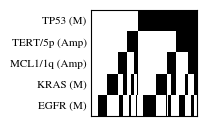

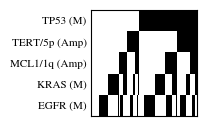

In [250]:
np.random.seed(0)
sim_data = pd.DataFrame(model.sample_artificial_data(1000), columns=model.events)

import importlib
importlib.reload(plotting)

for name, _data in [
    ("", data),
    ("_sim", sim_data),
]:
    fig, ax = plt.subplots(figsize=(2.3, 1.3))
    plotting.oncoplot(_data, ax)
    fig.tight_layout()
    fig.savefig(f"results/oncoplot{name}.pdf", dpi=600)

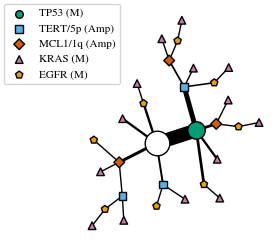

In [239]:
fig, ax = plt.subplots(figsize=(3, 2.5))
model.plot_order_tree(states=sim_data.to_numpy(), legend=True,
                      max_event_num=5, min_number_of_occurrence=1, ax=ax)

legends = list()
for child in ax.get_children():
    if isinstance(child, mpl.legend.Legend):
        legends.append(child)

for legend in legends[1:]:
    legend.set_visible(False)
legends[0].set_bbox_to_anchor((0.45, 1.05))

marker_dict = {label._text: handle for label, handle in zip(
    legends[0].texts, legends[0].legend_handles)}

ax.set_xlim(-7, None)
fig.tight_layout()
fig.savefig("results/tree.pdf")

In [35]:
states = data.groupby(data.columns.to_list()).value_counts(
).sort_values(ascending=False)[:3]
states = states.index.to_numpy()
states = [list(state) for state in states]
states = np.array(states)

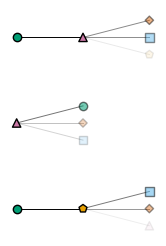

In [240]:
fig, ax = plt.subplots(figsize=(1.7, 2.5))

for i, state in enumerate(states):
    order = model.likeliest_order(state)[1]
    for i_o, i_e in enumerate(order):
        if i_o != 0:
            plt.plot([i_o-1, i_o], [i, i], zorder=0, color="black", lw=0.7)
        event = model.events[i_e]
        ax.scatter(
            [i_o], [i],
            facecolors=marker_dict[event].get_facecolor(),
            edgecolors=marker_dict[event].get_edgecolor(),
            marker=marker_dict[event].get_paths()[0],
        )
    probs = model.compute_next_event_probs(state)
    for i_ne, next_event in enumerate(np.argsort(probs)[:-4:-1]):
        next_event_name = model.events[next_event]
        ax.scatter(
            [len(order)], [i+0.2 - 0.2 * i_ne],
            facecolors=marker_dict[next_event_name].get_facecolor(),
            edgecolors=marker_dict[next_event_name].get_edgecolor(),
            marker=marker_dict[next_event_name].get_paths()[0],
            alpha=probs[next_event]
        )
        plt.plot([len(order) - 1, len(order)],
                 [i, i+0.2 - 0.2 * i_ne], zorder=0, color="black",
                 alpha=probs[next_event], lw=0.7

                 )

ax.axis("off")
fig.tight_layout()
fig.savefig("results/next_event.pdf")

In [146]:
positions = mcmc_analysis._sample_positions(
    log_theta=model.log_theta.flatten(),
    trajectory_num=500000, n_bins=100, seed=1)

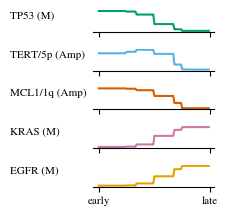

In [259]:
fig, ax = plt.subplots(
    # (n_events-1)//2+1, 2,
    n_events,
    figsize=(2.3, 2.2), sharex=True)
for i in range(n_events):
    # a = ax[i//2, i%2]
    a = ax[i]
    event = model.events[i]
    a.plot(positions[i],
            color=marker_dict[event].get_facecolor()
            # color="black"
            )
    for spine in ["top", "left", "right"]:
        a.spines[spine].set_visible(False)
    a.set_xticks([0, 100])
    a.set_yticks([])
    a.set_xticklabels(["early", "late"])
    a.set_ylabel(event, rotation=0, ha="left", labelpad=60)
fig.tight_layout()
fig.savefig("results/positions.pdf")

In [193]:
risks = mcmc_analysis._sample_risks(
    log_theta=model.log_theta.flatten(),
    trajectory_num=500, seed=2, data=data)

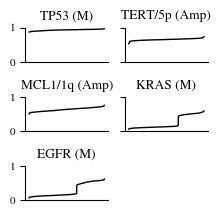

In [261]:
fig, ax = plt.subplots(
    # ncols=n_events,
    ncols=2, nrows=(n_events-1)//2 + 1,
    figsize=(2.3, 2.2), sharey=True)

for i in range(n_events):

    # a = ax[i]
    a = ax[i//2, i%2]

    data_filtered = data.reset_index(drop=True)[
        data.reset_index(drop=True).iloc[:, i] == 0]
    sorting = None

    risk = risks[data_filtered.index, i]
    risk.sort()
    a.plot(risk,
           lw=1, color="black")
    for side in ["top", "right"]:
        a.spines[side].set_visible(False)
    a.set_xticks([])
    a.set_title(f"{data.columns[i]}")
    a.set_ylim(0,1)
ax[-1, -1].axis("off")
fig.tight_layout()
fig.savefig("results/mutation_risks.pdf")